<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `PPSimExample.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Follows the MATLAB recursive-CIF workflow with the native Python `CIF.simulateCIF` path and all 9 published figures. Only inherent Simulink vs Python solver timing and stochastic draws differ.

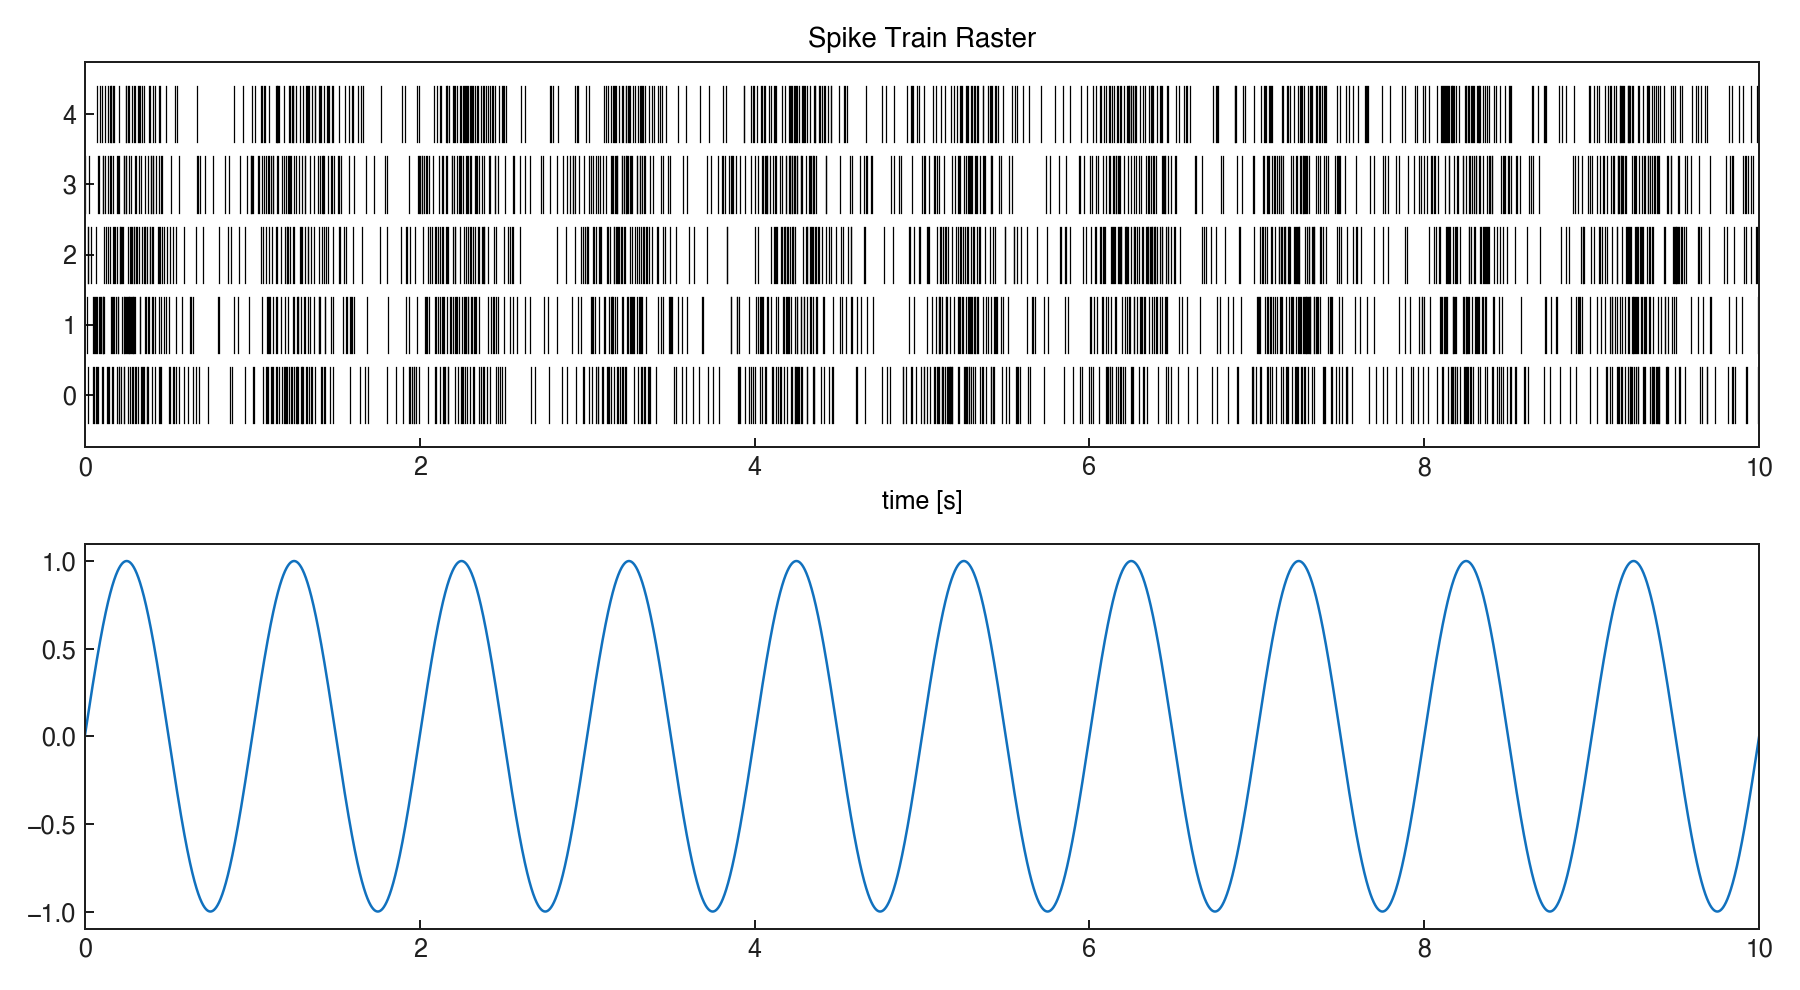

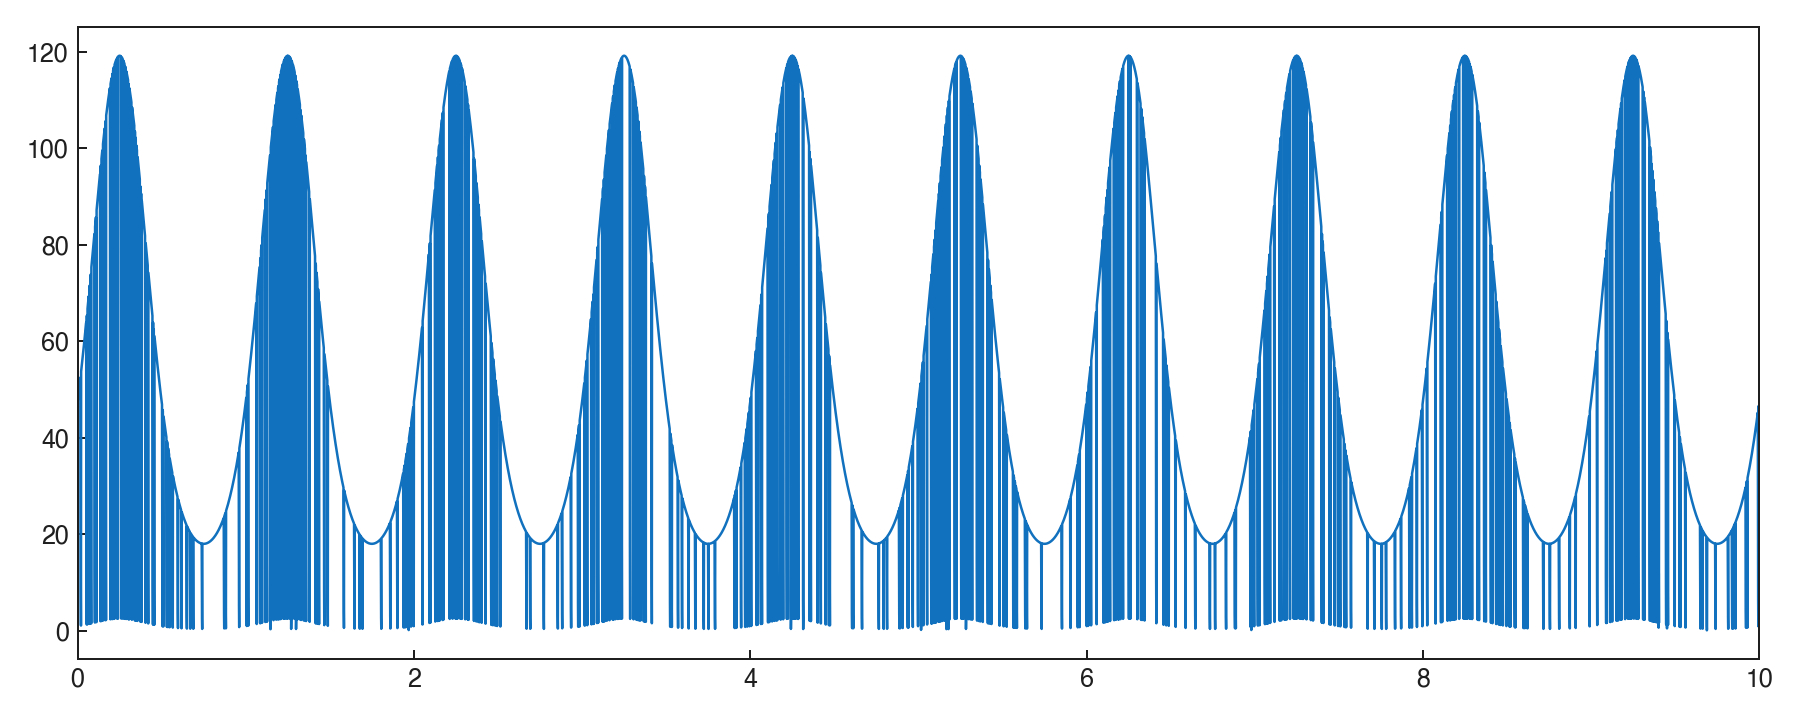

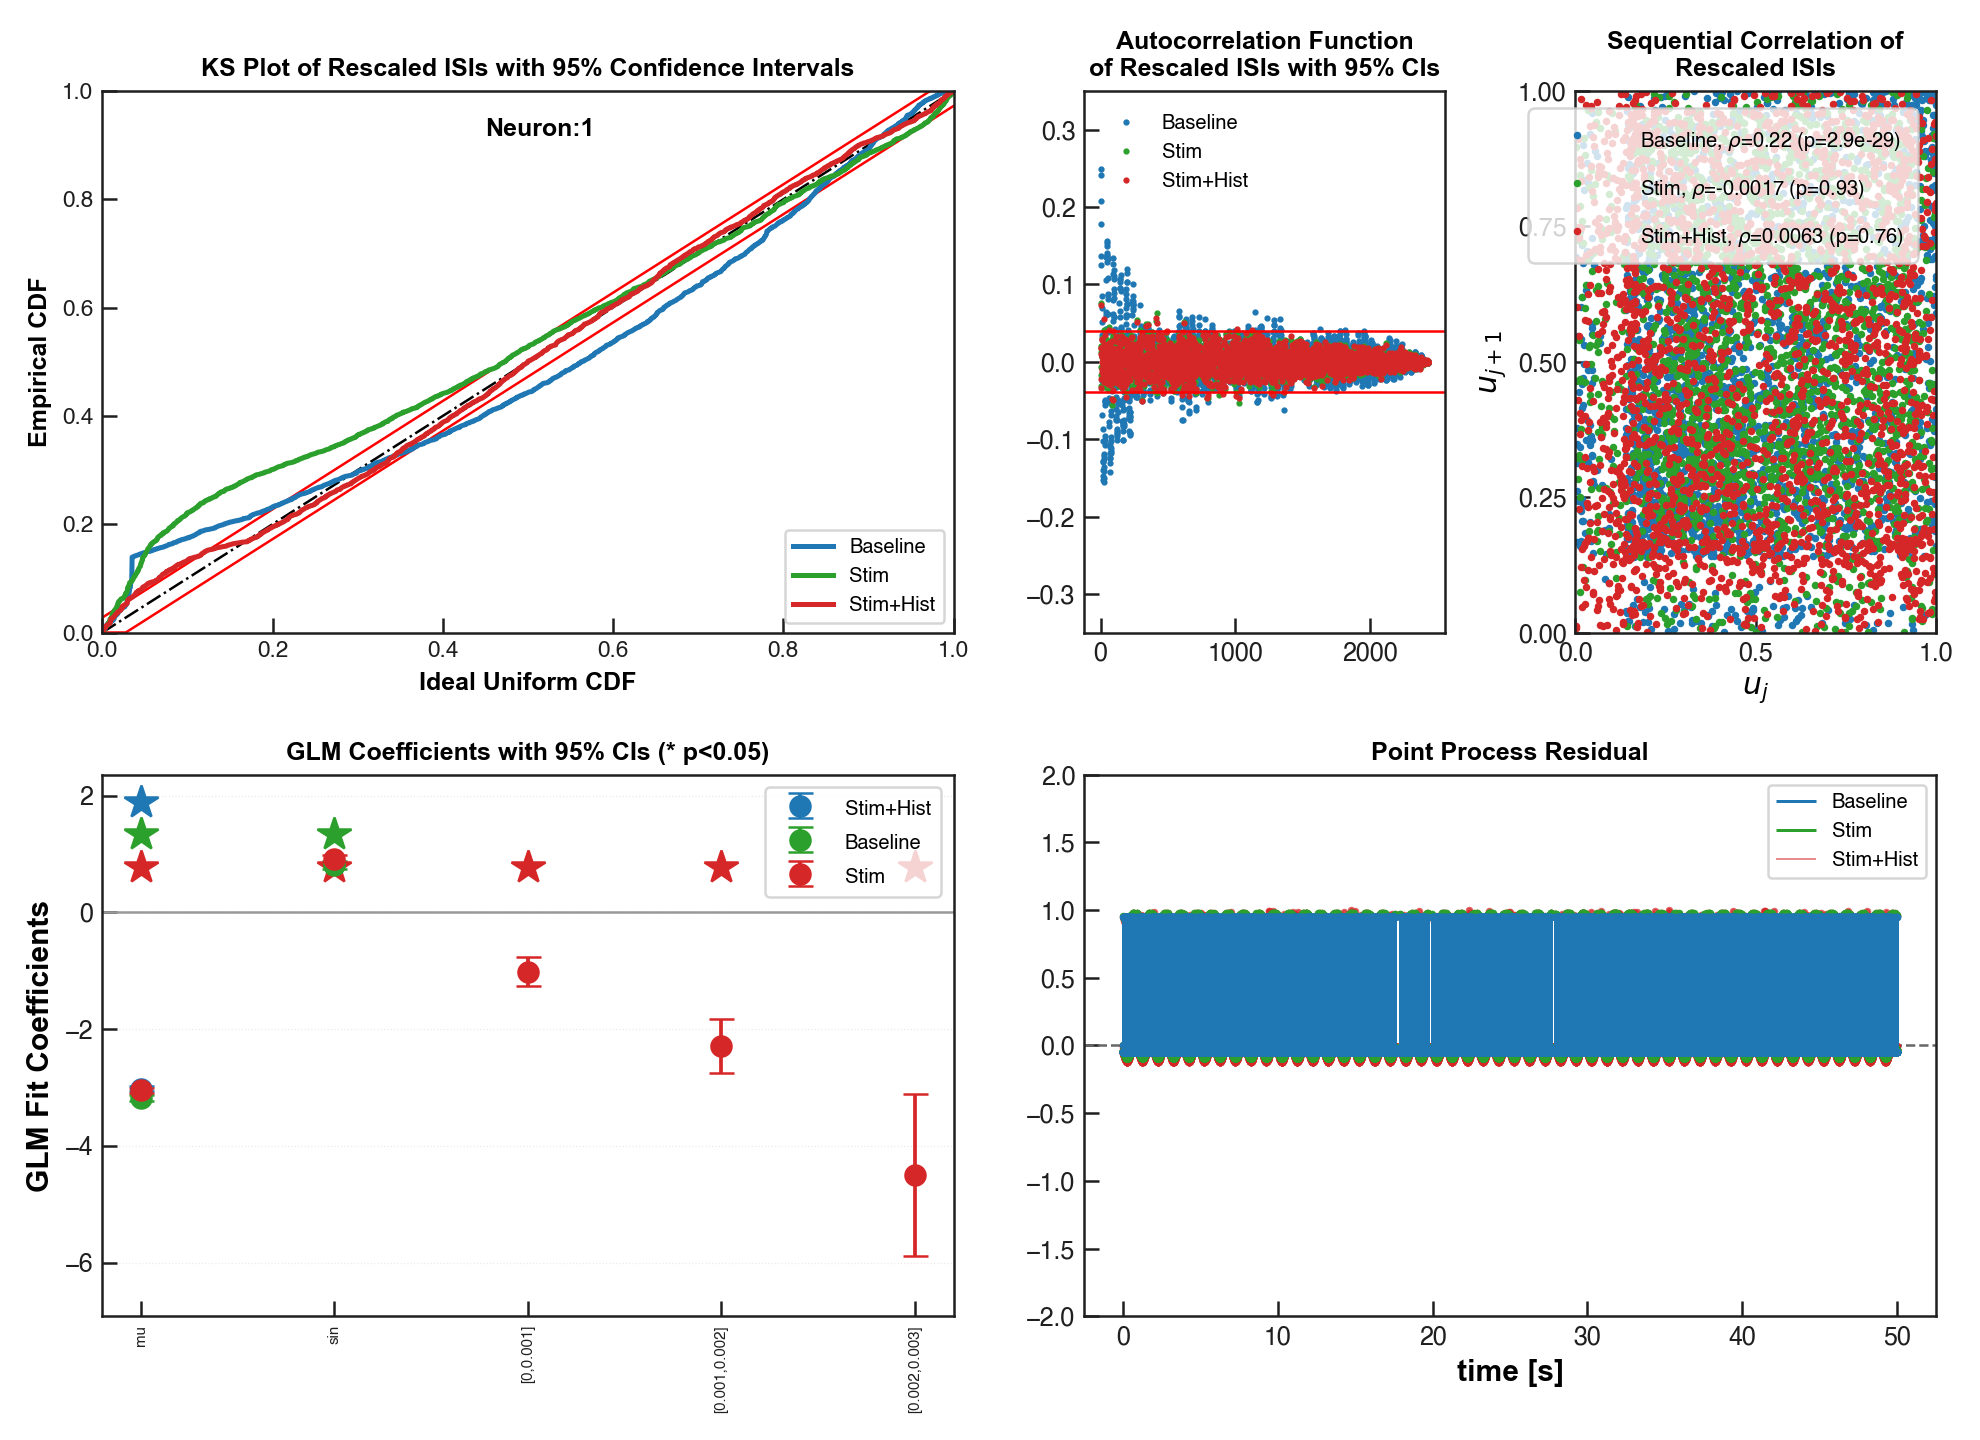

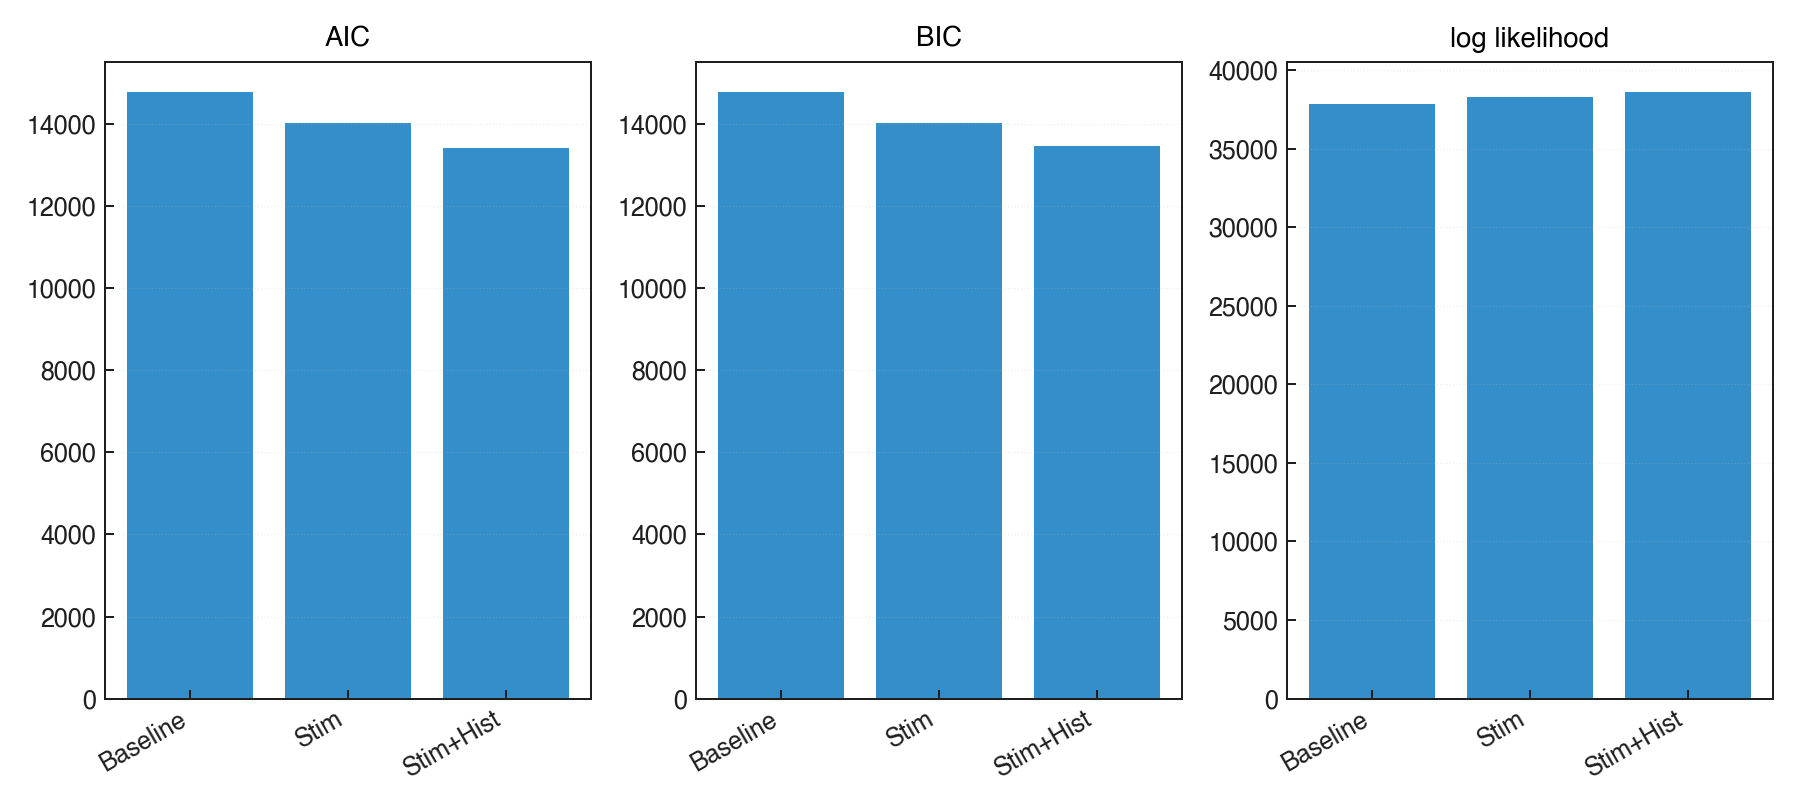

In [ ]:
# nSTAT-python notebook example: PPSimExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, CIF, ConfigColl, CovColl, Covariate, FitResSummary, Trial, TrialConfig
from nstat.notebook_figures import FigureTracker

np.random.seed(5)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='PPSimExample', output_root=OUTPUT_ROOT, expected_count=4)

def _figure(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig

Ts = 0.001
tMin = 0.0
tMax = 50.0
t = np.arange(tMin, tMax + Ts, Ts)
mu = -3.0


# General Point Process Simulation

In this demo, we show how sample-paths of a point process (PP) can be generated from specification of its conditional intensity function (CIF). We then use the generated PP data to validate the outputs of the Neural Spike Analysis Toolbox.

In [2]:
# SECTION 1: General Point Process Simulation
plt.close("all")

# Point Process Sample Path Generation

That both the stimulus effect and ensemble effects can be made into multi-input/multi-output transfer functions to account for more than 1 stimulus effect or multiple neighboring neuron effects. To do this, simply define E$ orS$ to be a row vector of LTI transfer functions. Make sure than the number of dimensions of the input matches the number of transfer functions specified in the row vector.

This block diagram specifies a conditional intensity function of the form

\lambda_{i} \cdot \Delta = exp(\mu_{i} + H*\Delta N_{i}[n] + S*u_{stim}[n] + E*\Delta N_{k}[n])/(1+exp(\mu_{i} + H*\Delta N_{i}[n] + S*u_{stim}[n] + E*\Delta N_{k}[n]))

In [3]:
# SECTION 2: Point Process Sample Path Generation
print("Using native Python CIF.simulateCIF to mirror the MATLAB recursive-CIF workflow.")

Using native Python CIF.simulateCIF to mirror the MATLAB recursive-CIF workflow.


# History Effect

1*h[n]=-1*\Delta N[n-1]-2*\Delta N[n-2] -4*\Delta N[n-3]

In [ ]:
# SECTION 3: History Effect
H = np.array([-1.0, -2.0, -4.0], dtype=float)
selfHist = [0.0, 0.001, 0.002, 0.003]
print({"history_windows_s": selfHist})


# Stimulus Effect

1*s[n]=1*u_{stim}[n]

In [ ]:
# SECTION 4: Stimulus Effect
S = np.array([1.0], dtype=float)
print({"stimulus_frequency_hz": 1.0, "stimulus_amplitude": 1.0})


# Ensemble Effect

1*e[n]=0*\Delta N_{k}[n]

In [ ]:
# SECTION 5: Ensemble Effect
E = np.array([0.0], dtype=float)
print({"ensemble_effect": 0.0})

# Generate the sample paths from the CIF (MATLAB %% untitled block following
# Ensemble Effect): drive the model with a 1 Hz sine wave, zero ensemble
# input, and use binomial conditional intensity.
f = 1.0
u = np.sin(2 * np.pi * f * t)
e = np.zeros_like(t)
stim = Covariate(t, u, "Stimulus", "time", "s", "Voltage", ["sin"])
ens = Covariate(t, e, "Ensemble", "time", "s", "Spikes", ["n1"])
numRealizations = 5
fitType = "binomial"
sC, lambda_cov = CIF.simulateCIF(mu, H, S, E, stim, ens, numRealizations, fitType, seed=5, return_lambda=True)

# MATLAB: figure; subplot(2,1,1); sC.plot; subplot(2,1,2); stim.plot
fig = _figure("figure; subplot(2,1,1); sC.plot; subplot(2,1,2); stim.plot", figsize=(10.0, 5.5))
ax1 = fig.add_subplot(2, 1, 1)
sC.plot(handle=ax1)
ax1.set_xlim(0.0, tMax / 5.0)
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)
stim.plot(handle=ax2)
ax2.set_xlim(0.0, tMax / 5.0)

# Companion view: plot the underlying conditional intensity (lambda)
fig = _figure("figure; lambda.plot", figsize=(10.0, 4.0))
ax = fig.add_subplot(1, 1, 1)
lambda_cov.getSubSignal(0).plot(handle=ax)
ax.set_xlim(0.0, tMax / 5.0)


# GLM Model Fitting Setup

In this section, we create the appropriate structures to fit several GLM models to the data generated above.

In [ ]:
# SECTION 6: GLM Model Fitting Setup
# Create a constant covariate representing the mean firing rate mu_i,
# package the simulated spikes + covariates into a Trial, and pick the GLM
# algorithm. (MATLAB ``baseline = Covariate(...); spikeColl = sC;
# cc = CovColl({stim, baseline}); trial = Trial(spikeColl, cc); ...``.)
baseline = Covariate(t, np.ones_like(t), "Baseline", "time", "s", "", ["mu"])
spikeColl = sC
cc = CovColl([stim, baseline])
sampleRate = 1.0 / Ts
trial = Trial(spikeColl, cc)
Algorithm = "BNLRCG"
print({"algorithm": Algorithm, "binary_representation": bool(sC.getNST(0).isSigRepBinary())})


# GLM Model Fitting and Results

Fit only a mean firing rate

Fit a mean firing rate + the stimulus term

Fit a mean firing rate, self-history, and stimulus --- Same as true model

Place all configurations together and run analysis for each neuron

In [ ]:
# SECTION 7: GLM Model Fitting and Results
# Build the three TrialConfig variants (baseline only, baseline+stimulus,
# baseline+stimulus+self-history), bundle them in a ConfigColl, and run the
# analysis for every neuron in the spike collection. Mirrors MATLAB's
# ``c{1}=TrialConfig(...); c{2}=...; c{3}=...; cfgColl=ConfigColl(c);
# results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, 0, Algorithm)``.
cfg = [
    TrialConfig([["Baseline", "mu"]], sampleRate=sampleRate, name="Baseline"),
    TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate=sampleRate, name="Stim"),
    TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate=sampleRate, history=selfHist, name="Stim+Hist"),
]
cfgColl = ConfigColl(cfg)
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl)


In [12]:
# SECTION 8: Results for sample neuron
fig = _figure("results{1}.plotResults", figsize=(11.0, 8.0))
results[0].plotResults(handle=fig)

<Figure size 1100x800 with 5 Axes>

In [17]:
# SECTION 9: Results for across all sample paths
summary = FitResSummary(results)
fig = _figure("Summary.plotSummary", figsize=(10.0, 4.5))
summary.plotSummary(handle=fig)
print({"fit_names": summary.fitNames, "mean_AIC": np.asarray(summary.meanAIC, dtype=float).round(3).tolist()})
__tracker.finalize()

{'fit_names': ['Baseline', 'Stim', 'Stim+Hist'], 'mean_AIC': [14768.013, 14013.036, 13415.194]}
